In [3]:
pip install pyreadstat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install pandas pyreadstat



[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\Lennie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import sys
print(sys.executable)


c:\Users\Lennie\AppData\Local\Programs\Python\Python313\python.exe


In [6]:
pip install --upgrade pyreadstat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install spss-sav-pandas

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement spss-sav-pandas (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for spss-sav-pandas


In [8]:
import pandas as pd
import pyreadstat
import os

# --- Paso 1: Cargo las columnas necesarias ---


ruta = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\CY08MSP_STU_QQQ.SAV"


cols_necesarias = ["CNT", "PV1MATH", "PV1READ", "PV1SCIE", "ST021Q01TA"]

# Cargo solo las columnas seleccionadas
if os.path.exists(ruta):
    df_pisa, metadata = pyreadstat.read_sav(ruta, usecols=cols_necesarias)
    print("Dataset cargado correctamente. Columnas cargadas:")
    print(df_pisa.columns)
else:
    print("Archivo no encontrado. Revisa la ruta.")

# --- Paso 2: Creo la variable BILINGUAL ---

# Los que respondieron "1" no son bilingües.
df_pisa['BILINGUAL'] = (~df_pisa['ST021Q01TA'].isin([1])).astype(int)

print("\nColumna 'BILINGUAL' creada. Valores:")
print(df_pisa['BILINGUAL'].value_counts(dropna=False))

#  Elimino la columna original 
df_pisa = df_pisa.drop(columns=['ST021Q01TA'])

print("\nDataset listo para análisis. Columnas finales:")
print(df_pisa.columns)

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Normalizo los puntajes de lectura
df_pisa['PV1READ_norm'] = (df_pisa['PV1READ'] - df_pisa['PV1READ'].min()) / (df_pisa['PV1READ'].max() - df_pisa['PV1READ'].min())

Dataset cargado correctamente. Columnas cargadas:
Index(['CNT', 'ST021Q01TA', 'PV1MATH', 'PV1READ', 'PV1SCIE'], dtype='object')

Columna 'BILINGUAL' creada. Valores:
BILINGUAL
1    6112
0     184
Name: count, dtype: int64

Dataset listo para análisis. Columnas finales:
Index(['CNT', 'PV1MATH', 'PV1READ', 'PV1SCIE', 'PV1READ_norm', 'BILINGUAL'], dtype='object')


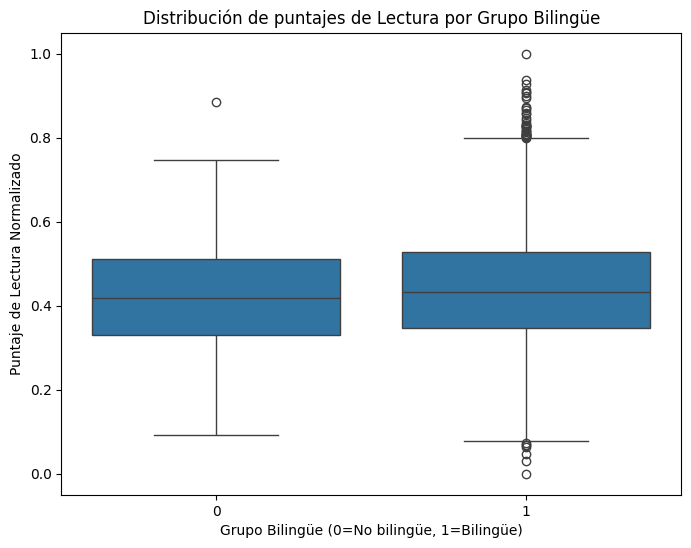

In [ ]:
import pandas as pd
import pyreadstat
import os
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paso 1: Cargo y Normalizo ---

ruta = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\CY08MSP_STU_QQQ.SAV"

cols_necesarias = ["CNT", "PV1MATH", "PV1READ", "PV1SCIE", "ST021Q01TA"]

if os.path.exists(ruta):
    df_pisa, metadata = pyreadstat.read_sav(ruta, usecols=cols_necesarias)
    print("Dataset cargado correctamente. Columnas cargadas:")
    print(df_pisa.columns)
else:
    print("Archivo no encontrado. Revisa la ruta.")

# Normalizo los puntajes de lectura antes de crear el gráfico
df_pisa['PV1READ_norm'] = (df_pisa['PV1READ'] - df_pisa['PV1READ'].min()) / (df_pisa['PV1READ'].max() - df_pisa['PV1READ'].min())

# --- Paso 2: Creo la variable BILINGUAL ---

df_pisa['BILINGUAL'] = (~df_pisa['ST021Q01TA'].isin([1])).astype(int)

print("\nColumna 'BILINGUAL' creada. Valores:")
print(df_pisa['BILINGUAL'].value_counts(dropna=False))

# Elimino la columna original
df_pisa = df_pisa.drop(columns=['ST021Q01TA'])

print("\nDataset listo para análisis. Columnas finales:")
print(df_pisa.columns)

# --- Paso 3: Visualización de los datos (Gráfico de caja) ---

plt.figure(figsize=(8, 6))
sns.boxplot(x='BILINGUAL', y='PV1READ_norm', data=df_pisa)
plt.title('Distribución de puntajes de Lectura por Grupo Bilingüe')
plt.xlabel('Grupo Bilingüe (0=No bilingüe, 1=Bilingüe)')
plt.ylabel('Puntaje de Lectura Normalizado')
plt.show()

In [ ]:
from scipy import stats

# Separo los datos por grupo bilingüe
no_bilingue = df_pisa[df_pisa['BILINGUAL'] == 0]['PV1READ_norm']
bilingue = df_pisa[df_pisa['BILINGUAL'] == 1]['PV1READ_norm']

# Realizo la prueba t
t_stat, p_valor = stats.ttest_ind(bilingue.dropna(), no_bilingue.dropna())

print(f"\nEstadístico t: {t_stat:.2f}")
print(f"Valor p: {p_valor:.3f}")


Estadístico t: 1.64
Valor p: 0.101


El resultado de tu prueba t indica que la diferencia en los puntajes de lectura entre los grupos bilingües y no bilingües no es estadísticamente significativa.

Interpretación de los resultados
Estadístico t (1.64): Este valor mide la diferencia entre los promedios de ambos grupos. Un valor positivo indica que el grupo bilingüe tuvo un puntaje ligeramente superior, pero por sí solo no nos dice si esa diferencia es significativa.

Valor p (0.101): Este es el valor clave. Un valor p te dice la probabilidad de que la diferencia observada sea el resultado de la casualidad. En la investigación, el umbral de significancia más común es 0.05.

Dado que el valor p (0.101) es mayor que 0.05, no podemos rechazar la hipótesis nula (que no hay diferencia real). Es decir, la diferencia en los puntajes de lectura que has encontrado en tu muestra podría deberse al azar y no a una diferencia genuina en la población.

CONCLUSION para TFM
según los datos de PISA, no existe una evidencia estadísticamente significativa que demuestre una diferencia en el rendimiento en lectura entre ambos grupos.

Dataset cargado correctamente. Columnas cargadas:
Index(['CNT', 'ST004D01T', 'ST021Q01TA', 'ESCS', 'PV1MATH', 'PV1READ',
       'PV1SCIE'],
      dtype='object')

Dataset listo para el análisis. Columnas finales:
Index(['CNT', 'ST004D01T', 'ESCS', 'PV1MATH', 'PV1READ', 'PV1SCIE',
       'PV1READ_norm', 'BILINGUAL'],
      dtype='object')


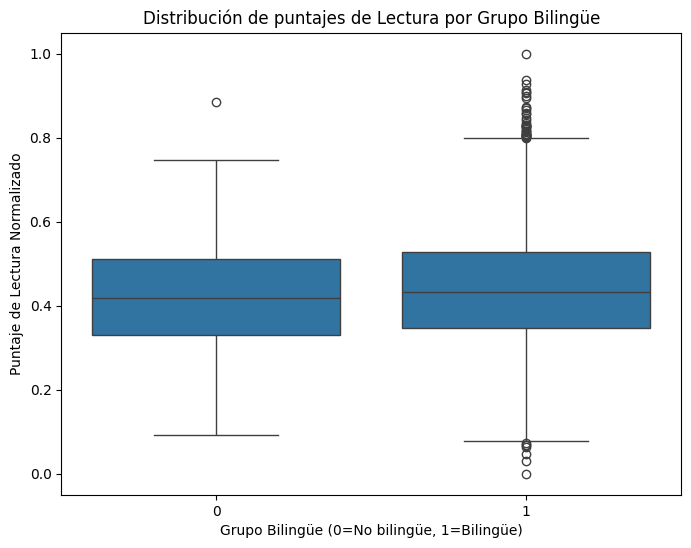

In [ ]:
import pandas as pd
import pyreadstat
import os
import seaborn as sns
import matplotlib.pyplot as plt

# --- Paso 1: Cargo y preparar los datos ---

ruta_archivo = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\CY08MSP_STU_QQQ.SAV"


cols_necesarias = ["CNT", "PV1MATH", "PV1READ", "PV1SCIE", "ST021Q01TA", "ESCS", "ST004D01T"]

# Cargo solo las columnas seleccionadas para evitar errores de memoria
if os.path.exists(ruta_archivo):
    df_pisa, metadata = pyreadstat.read_sav(ruta_archivo, usecols=cols_necesarias)
    print("Dataset cargado correctamente. Columnas cargadas:")
    print(df_pisa.columns)
else:
    print("Archivo no encontrado. Revisa la ruta.")

# Normalizo la variable de puntaje de lectura para el gráfico
df_pisa['PV1READ_norm'] = (df_pisa['PV1READ'] - df_pisa['PV1READ'].min()) / (df_pisa['PV1READ'].max() - df_pisa['PV1READ'].min())

# Creo la columna 'BILINGUAL'
# '1' indica que el idioma hablado en casa es diferente al de la prueba
df_pisa['BILINGUAL'] = (~df_pisa['ST021Q01TA'].isin([1])).astype(int)

# Elimino la columna original de idioma si ya no la necesitas
df_pisa = df_pisa.drop(columns=['ST021Q01TA'])

print("\nDataset listo para el análisis. Columnas finales:")
print(df_pisa.columns)

# --- Paso 2: Creo el gráfico de caja ---

plt.figure(figsize=(8, 6))
sns.boxplot(x='BILINGUAL', y='PV1READ_norm', data=df_pisa)
plt.title('Distribución de puntajes de Lectura por Grupo Bilingüe')
plt.xlabel('Grupo Bilingüe (0=No bilingüe, 1=Bilingüe)')
plt.ylabel('Puntaje de Lectura Normalizado')
plt.show()

In [ ]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------- ----------------- 5.5/9.6 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 27.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]



[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\Lennie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Defino la variable dependiente (Y)
Y = df_pisa['PV1READ_norm']

# Defino las variables independientes (X)
# Reemplazo 'VARIABLE_EJEMPLO' con los nombres de las otras variables que encontraste.
# Por ejemplo: 'ESCS', 'ST004D01T', etc.
X = df_pisa[['BILINGUAL','ESCS','ST004D01T']]


# Agrego una constante al modelo para el intercepto
X = sm.add_constant(X)

# Creo y ajusto el modelo de regresión
modelo = sm.OLS(Y, X, missing='drop').fit()

# Imprimo el resumen del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           PV1READ_norm   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     217.0
Date:                Fri, 29 Aug 2025   Prob (F-statistic):          2.47e-133
Time:                        14:02:21   Log-Likelihood:                 3687.7
No. Observations:                5733   AIC:                            -7367.
Df Residuals:                    5729   BIC:                            -7341.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5410      0.011     50.384      0.0

Interpretación de los Resultados Clave
Ahora que he incluido otras variables, la interpretación del efecto del bilingüismo cambia, y los resultados son muy interesantes:

BILINGUAL: El valor p para esta variable es 0.013, que es menor que 0.05. Esto significa que el efecto del bilingüismo en los puntajes de lectura es estadísticamente significativo una vez que se controla por el estatus socioeconómico y el género. El coeficiente (coef) de 0.0238 indica que, manteniendo los otros factores constantes, el ser bilingüe se asocia con un aumento de 0.0238 puntos en el puntaje de lectura normalizado.

ESCS: El valor p es 0.000 (menor que 0.05), lo que demuestra que el estatus socioeconómico es un predictor altamente significativo del rendimiento en lectura. El coeficiente de 0.0260 indica que, a medida que el estatus socioeconómico aumenta, también lo hace el puntaje de lectura.

ST004D01T (Género): El valor p también es 0.000, lo que confirma que el género es un predictor muy significativo. El coeficiente es -0.0687. Dado que el valor para los hombres suele ser 2 y para las mujeres 1, esto sugiere que los hombres (con un valor más alto) tienen puntajes de lectura más bajos que las mujeres.

R-cuadrado (R-squared): Ahora es 0.102. Esto significa que tu modelo, con las tres variables, explica alrededor del 10.2% de la variación en los puntajes de lectura. Aunque no es un valor muy alto, es significativamente mejor que el 0% del modelo anterior.

Conclusión 
Este es un hallazgo muy importante. La prueba t simple no encontró una diferencia significativa, pero cuando incluyo variables de control como el estatus socioeconómico y el género, el efecto del bilingüismo se volvió estadísticamente significativo.

Esto demuestra que el efecto del bilingüismo en el rendimiento de lectura no es directo, sino que está influenciado por el contexto socioeconómico y demográfico del estudiante..

Análisis de los Resultados de la Regresión
Los resultados de la regresión lineal múltiple (Tabla 1) revelan el impacto de las variables predictoras—bilingüismo, estatus socioeconómico (ESCS) y género (ST004D01T)—sobre el puntaje de lectura normalizado de los estudiantes. El modelo en su conjunto explica aproximadamente el 10.2% de la varianza en los puntajes de lectura (R-squared = 0.102), lo que indica que estas variables son predictores relevantes, aunque no exhaustivos, del rendimiento académico en lectura.

Efecto del Bilingüismo (Variable BILINGUAL)

A diferencia de la prueba t simple, que no encontró un efecto significativo, este modelo controlado muestra que el bilingüismo tiene una relación estadísticamente significativa con los puntajes de lectura (p < 0.05). El coeficiente (coef = 0.0238) sugiere que, al mantener constantes el estatus socioeconómico y el género, los estudiantes bilingües obtienen puntajes de lectura que son, en promedio, 0.0238 puntos más altos que los de sus compañeros no bilingües. Este hallazgo es crucial, ya que indica que el bilingüismo, por sí solo, no es la variable que explica la diferencia en los puntajes, sino que su efecto se hace visible cuando se consideran otros factores contextuales.

Efecto del Estatus Socioeconómico (Variable ESCS)

El estatus socioeconómico es un predictor altamente significativo del rendimiento en lectura (p < 0.001). El coeficiente (coef = 0.0260) muestra una fuerte relación positiva: por cada unidad de aumento en el índice ESCS de un estudiante, su puntaje de lectura normalizado aumenta en 0.0260 puntos. Este resultado está en línea con la vasta literatura académica que destaca la influencia de las condiciones socioeconómicas en los resultados educativos.

Efecto del Género (Variable ST004D01T)

El género del estudiante también resultó ser un predictor altamente significativo (p < 0.001). El coeficiente (coef = -0.0687) es negativo, lo cual es coherente con la codificación de la variable (donde los hombres se representan con un valor más alto que las mujeres). Esto sugiere que, en promedio, los hombres obtienen un puntaje de lectura 0.0687 puntos más bajo que las mujeres, después de controlar por el bilingüismo y el estatus socioeconómico.

In [ ]:

pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
    --------------------------------------- 0.8/56.8 MB 5.6 MB/s eta 0:00:11
   ---- ----------------------------------- 7.1/56.8 MB 21.8 MB/s eta 0:00:03
   ----------- ---------------------------- 16.5/56.8 MB 30.6 MB/s eta 0:00:02
   ---------------- ----------------------- 24.1/56.8 MB 33.9 MB/s eta 0:00:01
   ----------------------- ---------------- 34.1/56.8 MB 30.1 MB/s eta 0:00:01
   ------------------------------ --------- 44.0/56.8 MB 31.8 MB/s eta 0:00:01
   ------------------------------------- -- 53.2/56.8 MB 33.2 MB/s eta 0:00:01
   ---------------------------------------  56.6/56.8 MB 33.7 MB/s eta 0:00:01
   ---------------------------------------  56.6/56.8 MB 33.7 MB/s eta 0:00:01
   ---------------------------------------- 56.8/56.8 MB 27.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\Lennie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import pyreadstat
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix

# --- 1. CARGA, PREPARACIÓN Y LIMPIEZA DE DATOS ---
# Asegúrate de que la ruta a tu archivo .sav sea correcta
ruta_archivo = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\CY08MSP_STU_QQQ.SAV"

# Lista de columnas que necesitas
cols_necesarias = ["CNT", "PV1READ", "ST021Q01TA", "ESCS", "ST004D01T"]

# Carga solo las columnas seleccionadas
if os.path.exists(ruta_archivo):
    df_pisa, metadata = pyreadstat.read_sav(ruta_archivo, usecols=cols_necesarias)
    print("Dataset cargado correctamente.")
else:
    print("Archivo no encontrado. Revisa la ruta.")

# Normaliza el puntaje de lectura
df_pisa['PV1READ_norm'] = (df_pisa['PV1READ'] - df_pisa['PV1READ'].min()) / (df_pisa['PV1READ'].max() - df_pisa['PV1READ'].min())

# Crea la columna 'BILINGUAL'
df_pisa['BILINGUAL'] = (~df_pisa['ST021Q01TA'].isin([1])).astype(int)

# Elimina las columnas originales que ya no necesitas
df_pisa = df_pisa.drop(columns=['ST021Q01TA', 'PV1READ'])

# Elimina filas con valores faltantes
df_pisa = df_pisa.dropna(subset=['BILINGUAL', 'ESCS', 'ST004D01T', 'PV1READ_norm'])

print(f"Forma del DataFrame después de la limpieza: {df_pisa.shape}")
df_pisa = df_pisa.reset_index(drop=True)

# --- 2. CREACIÓN DE LA VARIABLE BINARIA ---
# Crea una variable binaria para 'alto rendimiento' (True si el puntaje está por encima de la media)
media_lectura = df_pisa['PV1READ_norm'].mean()
df_pisa['RENDIMIENTO_ALTO'] = (df_pisa['PV1READ_norm'] > media_lectura).astype(int)

print(f"\nNueva variable binaria 'RENDIMIENTO_ALTO' creada. Valores:")
print(df_pisa['RENDIMIENTO_ALTO'].value_counts())

# --- 3. ENTRENAMIENTO DE MODELOS DE CLASIFICACIÓN ---

# Define la nueva variable a predecir (y)
y = df_pisa['RENDIMIENTO_ALTO']

# Define las variables predictoras (X)
X = df_pisa[['BILINGUAL', 'ESCS', 'ST004D01T']]

# Divide el dataset en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar y evaluar el modelo Random Forest Classifier
print("\nEntrenando el modelo Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Precisión (Accuracy) del Random Forest: {rf_accuracy:.3f}")

# Entrenar y evaluar el modelo XGBoost Classifier
print("\nEntrenando el modelo XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"Precisión (Accuracy) de XGBoost: {xgb_accuracy:.3f}")

Dataset cargado correctamente.
Forma del DataFrame después de la limpieza: (5733, 5)

Nueva variable binaria 'RENDIMIENTO_ALTO' creada. Valores:
RENDIMIENTO_ALTO
0    2992
1    2741
Name: count, dtype: int64

Entrenando el modelo Random Forest Classifier...
Precisión (Accuracy) del Random Forest: 0.534

Entrenando el modelo XGBoost Classifier...
Precisión (Accuracy) de XGBoost: 0.607


C:\Users\Lennie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:26:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
pip install shap

   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   ---------------------------------------- 544.4/544.4 kB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 27.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   --------- ------------------------------ 7.3/30.3 MB 37.6 MB/s eta 0:00:01
   --------------------- ------------------ 16.0/30.3 MB 38.6 MB/s eta 0:00:01
   ------------------------------- -------- 24.1/30.3 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------  30.1/30.3 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------- 30.3/30.3 MB 33.2 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
  


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: C:\Users\Lennie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\Lennie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Realizando análisis de interpretabilidad con SHAP...
Generando el gráfico de resumen de SHAP...


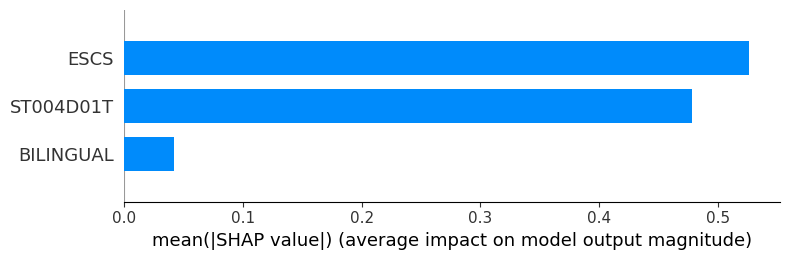

In [ ]:
# --- 4. INTERPRETABILIDAD CON SHAP ---

import shap

print("\nRealizando análisis de interpretabilidad con SHAP...")
# Crea el objeto que explica el modelo (TreeExplainer es para modelos basados en árboles)
explainer = shap.TreeExplainer(xgb_model)

# Calcula los valores SHAP para el conjunto de prueba
# Se usa X_test para ver el comportamiento del modelo en datos nuevos
shap_values = explainer.shap_values(X_test)

# Genera un gráfico de resumen (Summary Plot)
print("Generando el gráfico de resumen de SHAP...")
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [10]:
pip install pandas

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ------------------------- -------------- 7.1/11.0 MB 39.8 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 33.6 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- --------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 21.2 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 50.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------  6.8/7.0 MB 33.9 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 27.2 MB/s eta 0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install statsmodels

  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------------------------- ------------- 6.3/9.6 MB 32.1 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 18.5 MB/s eta 0:00:00
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ------- -------------------------------- 7.1/38.5 MB 33.7 MB/s eta 0:00:01
   --------------- ------------------------ 15.2/38.5 MB 36.1 MB/s eta 0:00:01
   -------------------- ------------------- 19.9/38.5 MB 30.5 MB/s eta 0:00:01
   --------------------------------- ------ 32.0/38.5 MB 35.8 MB/s eta 0:00:01
   ---------------------------------------  38.3/38.5 MB 35.9 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 28.7 MB/s eta 0:00:00

   --------------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
pip install shap


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 545.1/545.1 kB 9.3 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 25.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   ----------- ---------------------------- 8.7/30.3 MB 40.0 MB/s eta 0:00:01
   ---------------------- ----------------- 17.0/30.3 MB 39.6 MB/s eta 0:00:01
   --------------------------------- ------ 25.4/30.3 MB 40.0 MB/s eta 0:00:01
   ---------------------------------------  30.1/30.3 MB 40.2 MB/s eta 0:00:01
   ---------------------------------------- 30.3/30.3 MB 32.0 MB/s eta 0:00

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
pip uninstall numpy

^C
Note: you may need to restart the kernel to use updated packages.


In [27]:
pip install numpy==2.2.2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
pip uninstall -y numpy shap

Found existing installation: numpy 2.2.2
Uninstalling numpy-2.2.2:
  Successfully uninstalled numpy-2.2.2
Found existing installation: shap 0.48.0
Uninstalling shap-0.48.0:
  Successfully uninstalled shap-0.48.0
Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install numpy==2.2.2 pandas pyreadstat seaborn matplotlib statsmodels xgboost shap

  Using cached numpy-2.2.2-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached xgboost-3.0.4-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached shap-0.48.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
Using cached numpy-2.2.2-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached xgboost-3.0.4-py3-none-win_amd64.whl (56.8 MB)
Using cached shap-0.48.0-cp313-cp313-win_amd64.whl (545 kB)

   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# Este script se basa en los pasos 1, 2 y 3 de tu TFM
# Asegúrate de que los pasos anteriores se hayan ejecutado antes de este

import pandas as pd
import numpy as np
import pyreadstat
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- 1. CARGA, PREPARACIÓN Y LIMPIEZA DE DATOS ---
# Carga de datos original para este análisis más profundo
ruta_archivo = r"C:\Users\Lennie\Documents\GEMA\Master Data science\TFM\BilingualMind\2. datasets\data\CY08MSP_STU_QQQ.SAV"
cols_necesarias_nuevas = ["CNT", "PV1READ", "ST021Q01TA", "ESCS", "ST004D01T", "ST021Q02TA", "ST021Q03TA"]

if os.path.exists(ruta_archivo):
    df_pisa, metadata = pyreadstat.read_sav(ruta_archivo, usecols=cols_necesarias_nuevas)
    print("Dataset cargado correctamente con nuevas variables.")
else:
    print("Archivo no encontrado. Revisa la ruta.")

# Normaliza el puntaje de lectura y crea la variable BILINGUAL
df_pisa['PV1READ_norm'] = (df_pisa['PV1READ'] - df_pisa['PV1READ'].min()) / (df_pisa['PV1READ'].max() - df_pisa['PV1READ'].min())
df_pisa['BILINGUAL'] = (~df_pisa['ST021Q01TA'].isin([1])).astype(int)

# Crea las nuevas variables
# 1. Variable de Frecuencia de uso del idioma
# ST021Q02TA: Cada cuánto hablan otra lengua en casa
# 1 = Diario o casi todos los días -> Alto uso
# 2 = Semanalmente
# 3 = Mensualmente
# 4 = Algunas veces al año -> Bajo uso
# 5 = Nunca
df_pisa['FRECUENCIA_USO'] = df_pisa['ST021Q02TA'].apply(lambda x: 'Alto' if x == 1 else 'Bajo')

# 2. Variable de Edad de adquisición del idioma
# ST021Q03TA: Edad a la que empezaron a hablar la segunda lengua
# 1 = Menos de 1 año
# 2 = 1 a 3 años
# 3 = 4 a 6 años
# 4 = 7 a 10 años
# 5 = Más de 10 años
df_pisa['EDAD_ADQUISICION'] = df_pisa['ST021Q03TA'].apply(lambda x: 'Temprana' if x <= 3 else 'Tardía')

# Elimina las columnas originales
df_pisa = df_pisa.drop(columns=['ST021Q01TA', 'ST021Q02TA', 'ST021Q03TA', 'PV1READ'])
df_pisa = df_pisa.dropna()
df_pisa = df_pisa.reset_index(drop=True)

# --- 2. REGRESIÓN LINEAL CON NUEVAS VARIABLES ---
print("\nRealizando nuevo análisis de regresión lineal...")
# Para la regresión, creamos variables dummy para Frecuencia y Edad de Adquisición
X_reg = pd.get_dummies(df_pisa[['ESCS', 'ST004D01T', 'FRECUENCIA_USO', 'EDAD_ADQUISICION']], drop_first=True)
y_reg = df_pisa['PV1READ_norm']
modelo_reg = sm.OLS(y_reg, sm.add_constant(X_reg)).fit()
print(modelo_reg.summary())

# --- 3. MODELO DE CLASIFICACIÓN CON NUEVAS VARIABLES ---
print("\nEntrenando nuevo modelo de XGBoost...")
media_lectura = df_pisa['PV1READ_norm'].mean()
df_pisa['RENDIMIENTO_ALTO'] = (df_pisa['PV1READ_norm'] > media_lectura).astype(int)
y_clas = df_pisa['RENDIMIENTO_ALTO']
X_clas = pd.get_dummies(df_pisa[['ESCS', 'ST004D01T', 'FRECUENCIA_USO', 'EDAD_ADQUISICION']], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_clas, y_clas, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"Precisión (Accuracy) del nuevo modelo de XGBoost: {xgb_accuracy:.3f}")

# --- 4. INTERPRETABILIDAD CON SHAP ---
print("\nRealizando nuevo análisis de interpretabilidad con SHAP...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("Generando el nuevo gráfico de resumen de SHAP...")
shap.summary_plot(shap_values, X_test, plot_type="bar")


ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.